# Rashomon Set Tree Structure Analysis

Structural analysis of the PRAXIS Rashomon set (July 7 externship guidance): sample
trees from the **beginning** (lowest objective), **middle**, and **end** of the set,
diagram them, and characterize how the models change — depth, number of leaves,
which split variables appear/disappear, and how split thresholds move.

**Prerequisite**: run the export cell in [comparison.ipynb](comparison.ipynb) first;
it writes `results/praxis_trees.json` (all trees, ranked by objective).

In [2]:
import sys
sys.path.append('..')
import pandas as pd
from prxs import load_trees, draw_tree

payload = load_trees('../results/praxis_trees.json')
trees = payload['trees']          # ranked by objective: trees[r] has rank r
feature_names = payload['feature_names']
print(f"{payload['n_trees_total']} trees in the Rashomon set, {len(trees)} exported")
print(f"lambda_reg = {payload['lambda_reg']}")

# Feature-index → name mapping. Raw path entries are signed ids ±(index+1):
# +id means the condition holds ("yes" branch), -id means it doesn't
mapping = pd.DataFrame({
    'Column index': range(len(feature_names)),
    'Signed id (yes / no)': [f'+{i + 1} / -{i + 1}' for i in range(len(feature_names))],
    'Binarized feature': feature_names,
})
display(mapping)

140 trees in the Rashomon set, 140 exported
lambda_reg = 0.005


,Column index,Signed id (yes / no),Binarized feature
0,0,+1 / -1,Online_boarding <= 1.5
1,1,+2 / -2,Online_boarding <= 3.5
2,2,+3 / -3,Online_boarding <= 4.5
3,3,+4 / -4,Type_of_Travel_Personal Travel <= 0.5
4,4,+5 / -5,Class_Eco <= 0.5
5,5,+6 / -6,Inflight_wifi_service <= 0.5
6,6,+7 / -7,Inflight_wifi_service <= 1.5
7,7,+8 / -8,Inflight_wifi_service <= 2.5
8,8,+9 / -9,Inflight_wifi_service <= 3.5
9,9,+10 / -10,Inflight_wifi_service <= 4.5


In [3]:
# Hand-written translations for the diagrams — edit the values freely.
# RULE: phrase each label so the "yes" edge still means the raw condition
# (<= threshold) is TRUE. E.g. "Customer_Type_disloyal Customer <= 0.5" is true
# when disloyal == 0, hence "Loyal customer?".
# Use \n to control line breaks inside a node box. Entries left as raw names
# (or deleted) render as the raw name.
feature_labels = {
    'Online_boarding <= 1.5': 'Online boarding rated < 2?',
    'Online_boarding <= 2.5': 'Online boarding rated < 3?',
    'Online_boarding <= 3.5': 'Online boarding rated < 4?',
    'Online_boarding <= 4.5': 'Online boarding rated < 5?',
    'Type_of_Travel_Personal Travel <= 0.5': 'Not personal travel?',
    'Class_Eco <= 0.5': 'Economy class?',
    'Inflight_wifi_service <= 0.5': 'No WiFi service rating',
    'Inflight_wifi_service <= 1.5': 'WiFi service rated < 2?',
    'Inflight_wifi_service <= 2.5': 'WiFi service rated < 3?',
    'Inflight_wifi_service <= 3.5': 'WiFi service rated < 4?',
    'Inflight_wifi_service <= 4.5': 'WiFi service rated < 5?',
    'On_board_service <= 1.5': 'Boarding service rated < 2?',
    'On_board_service <= 2.5': 'Boarding service rated < 3?',
    'On_board_service <= 3.5': 'Boarding service rated < 4?',
    'On_board_service <= 4.5': 'Boarding service rated < 5?',
    'Customer_Type_disloyal Customer <= 0.5': 'Loyal customer?',
    'Inflight_entertainment <= 0.5': 'No inflight entertainment rating',
    'Inflight_entertainment <= 1.5': 'Inflight entertainment rated < 2?',
    'Inflight_entertainment <= 2.5': 'Inflight entertainment rated < 3?',
    'Inflight_entertainment <= 3.5': 'Inflight entertainment rated < 4?',
    'Inflight_entertainment <= 4.5': 'Inflight entertainment rated < 5?',
    'Checkin_service <= 1.5': 'Check-in service rated < 2?',
    'Checkin_service <= 2.5': 'Check-in service rated < 3?',
    'Checkin_service <= 4.5': 'Check-in service rated < 5?',
    'Leg_room_service <= 0.5': 'No leg room service rating',
    'Leg_room_service <= 1.5': 'Leg room service rated < 2?',
    'Leg_room_service <= 3.5': 'Leg room service rated < 4?',
    'Leg_room_service <= 4.5': 'Leg room service rated < 5?',
}

# Guard against typos: every key must be a real binarized feature name
unknown = set(feature_labels) - set(feature_names)
assert not unknown, f"Labels for nonexistent features: {unknown}"

## Structure summary (all trees)

In [4]:
summary = pd.DataFrame([{
    'Rank': t['rank'],
    'Loss': t.get('loss'),
    'Leaves': t['num_leaves'],
    'Depth': t['depth'],
    'Split features': ', '.join(t['split_features']),
} for t in trees])
display(summary)

print(f"Loss range: {summary['Loss'].min():.6f} - {summary['Loss'].max():.6f}")
print(f"Leaves range: {summary['Leaves'].min()} - {summary['Leaves'].max()}")
print(f"Depth range: {summary['Depth'].min()} - {summary['Depth'].max()}")

,Rank,Loss,Leaves,Depth,Split features
0,0,0.136402,8,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."
1,1,0.140635,9,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."
2,2,0.140635,9,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."
3,3,0.140670,8,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."
4,4,0.140695,8,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."
...,...,...,...,...,...
135,135,0.142995,10,5,"Checkin_service <= 2.5, Customer_Type_disloyal..."
136,136,0.142995,10,5,"Checkin_service <= 2.5, Customer_Type_disloyal..."
137,137,0.142995,10,5,"Checkin_service <= 2.5, Customer_Type_disloyal..."
138,138,0.143071,9,5,"Customer_Type_disloyal Customer <= 0.5, Inflig..."


Loss range: 0.136402 - 0.143071
Leaves range: 7 - 10
Depth range: 5 - 5


## Split-variable usage across the set

Which binarized features are load-bearing (used by every tree) vs interchangeable (used by only some)?

In [5]:
from collections import Counter

counts = Counter(f for t in trees for f in t['split_features'])
usage = pd.DataFrame(
    sorted(counts.items(), key=lambda kv: -kv[1]),
    columns=['Binarized feature', 'Trees using it']
)
usage['Share of set'] = (usage['Trees using it'] / len(trees)).round(3)
display(usage)

# Root split per tree: paths[0][0] is the first condition of the first leaf path,
# which is always the root node
root_splits = pd.Series(
    [feature_names[abs(t['paths'][0][0]) - 1] for t in trees]
).value_counts().rename('Trees with this root split')
display(root_splits.to_frame())

,Binarized feature,Trees using it,Share of set
0,Customer_Type_disloyal Customer <= 0.5,140,1.000
1,Inflight_entertainment <= 3.5,140,1.000
2,Inflight_wifi_service <= 0.5,140,1.000
3,Inflight_wifi_service <= 4.5,140,1.000
4,Type_of_Travel_Personal Travel <= 0.5,140,1.000
5,Inflight_wifi_service <= 3.5,138,0.986
6,Online_boarding <= 4.5,122,0.871
7,Online_boarding <= 3.5,24,0.171
8,Checkin_service <= 2.5,14,0.100
9,Online_boarding <= 1.5,6,0.043


,Trees with this root split
Inflight_wifi_service <= 0.5,140


## Tree diagrams: beginning / middle / end of the set

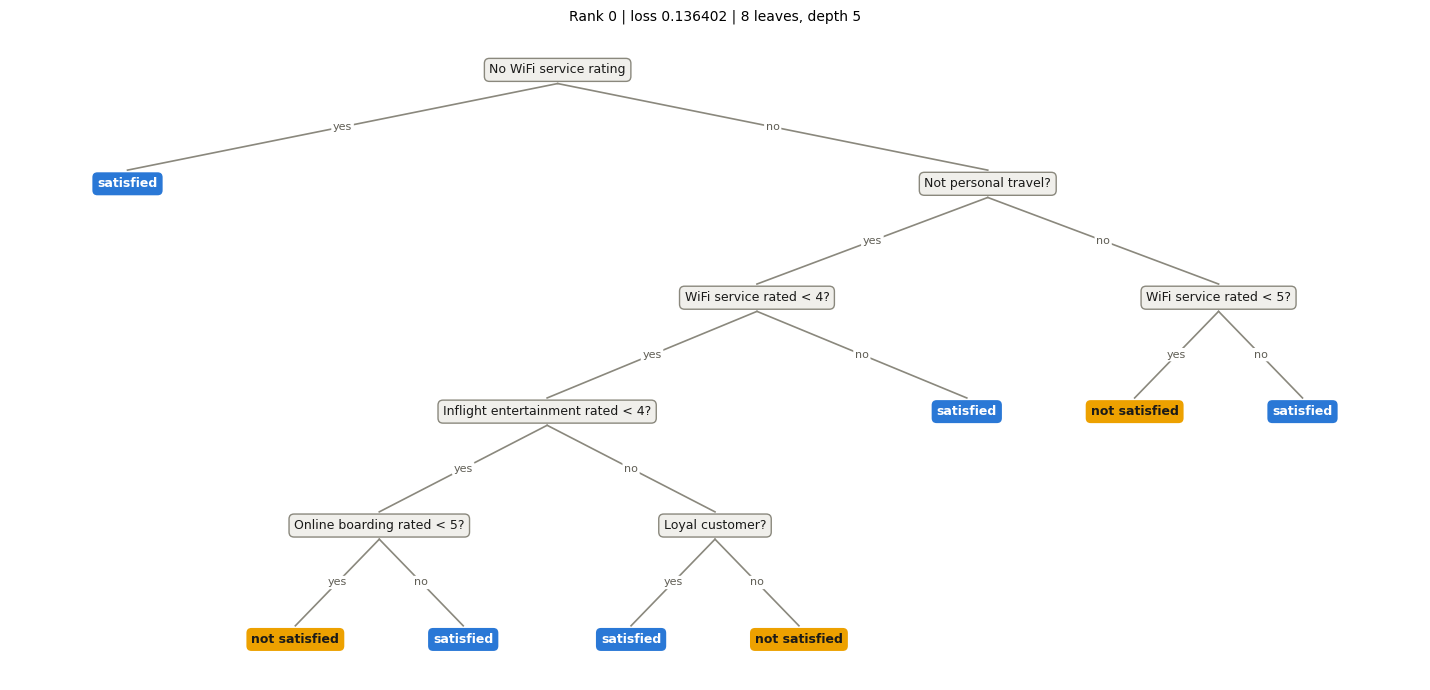

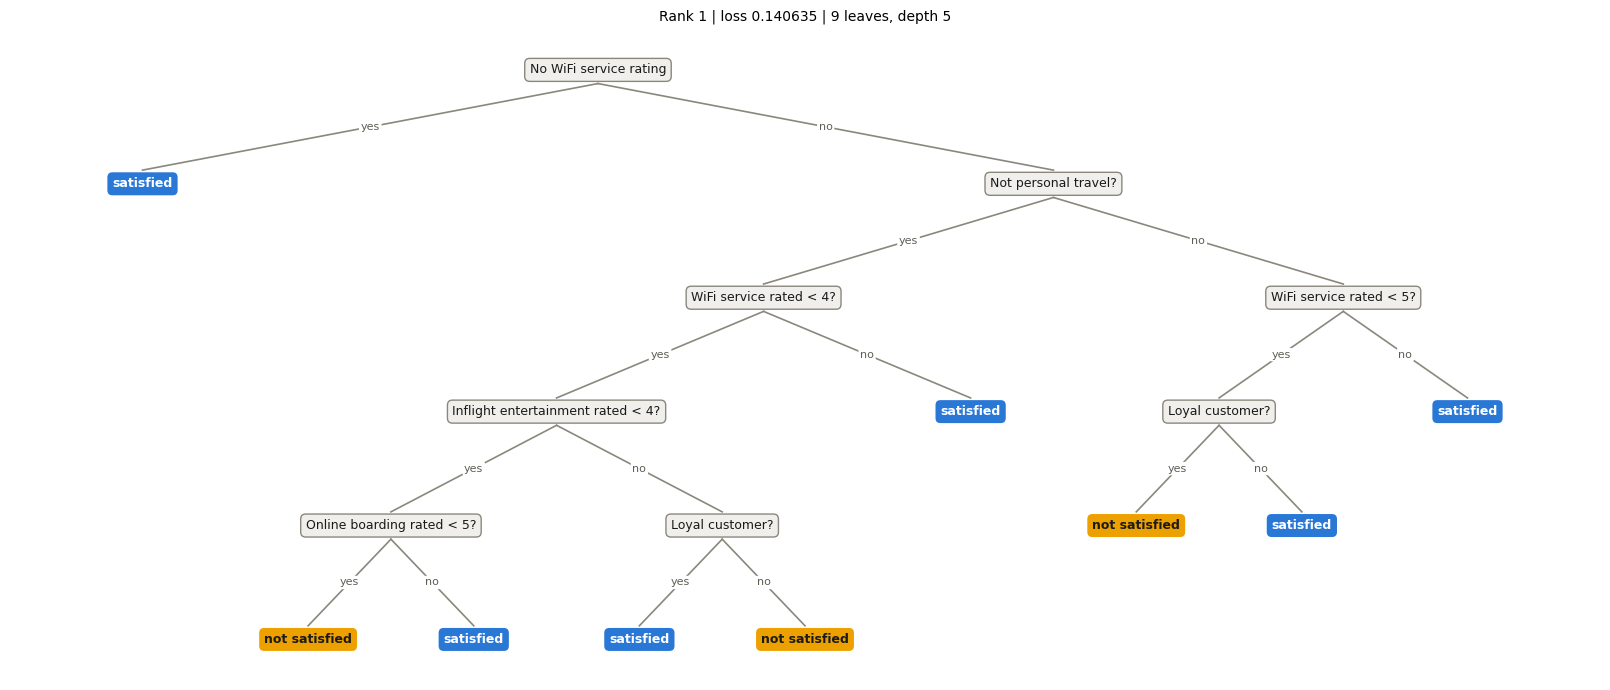

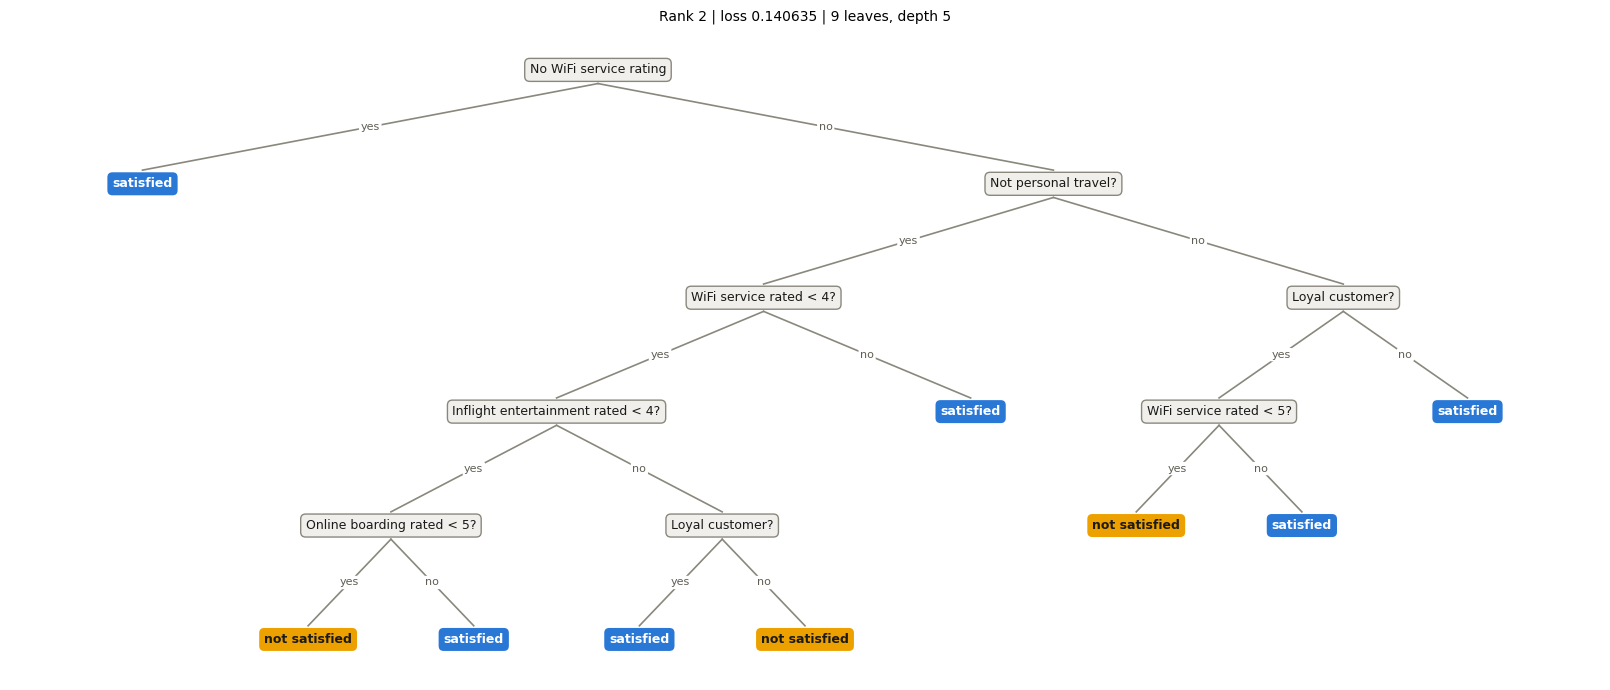

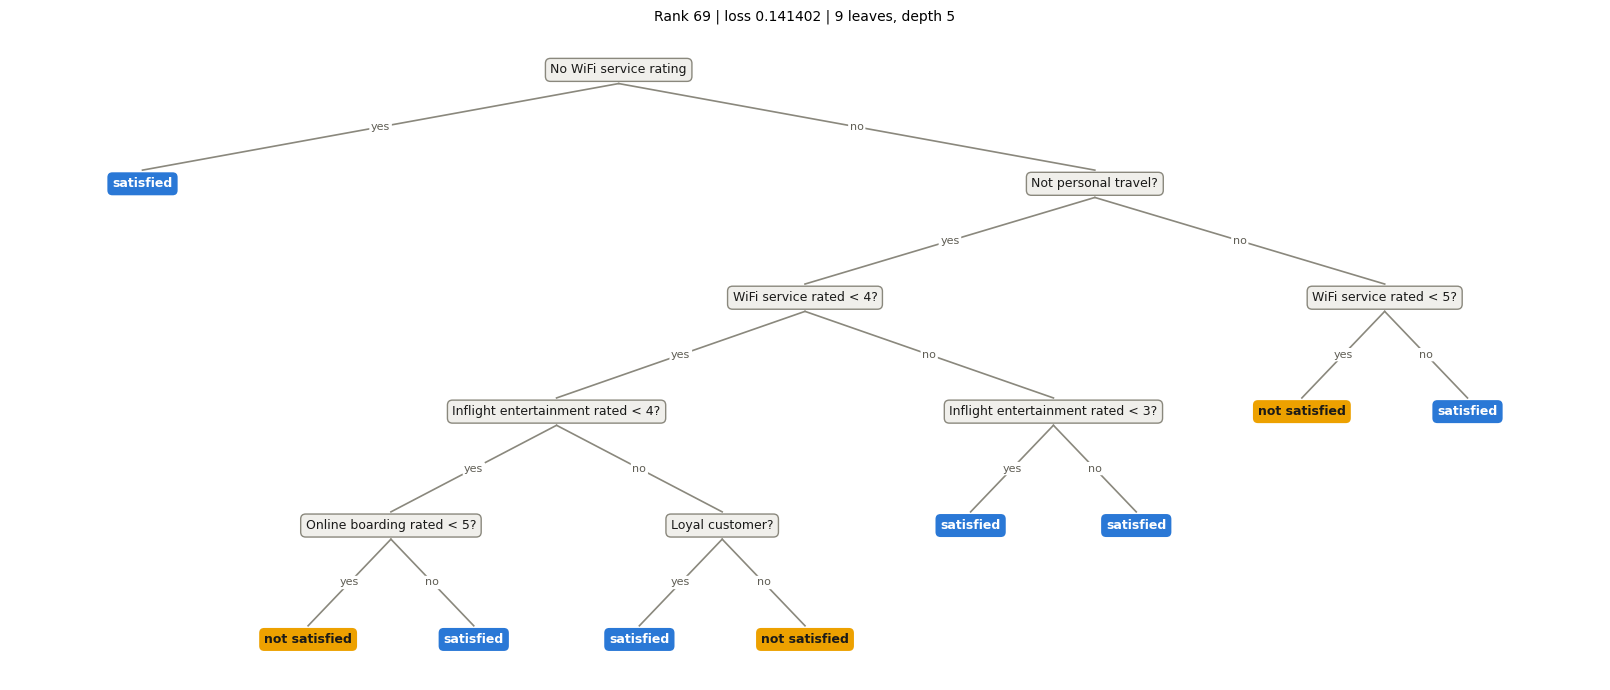

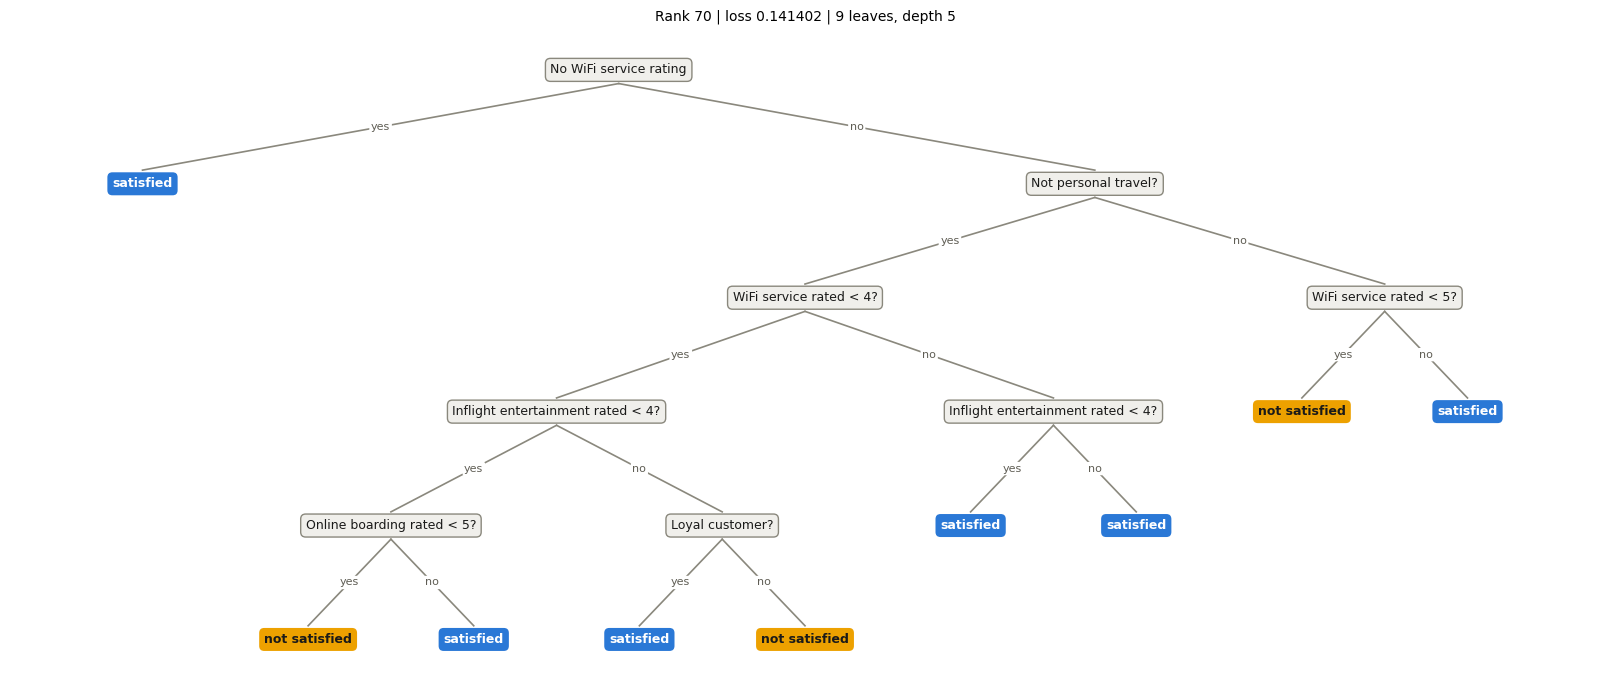

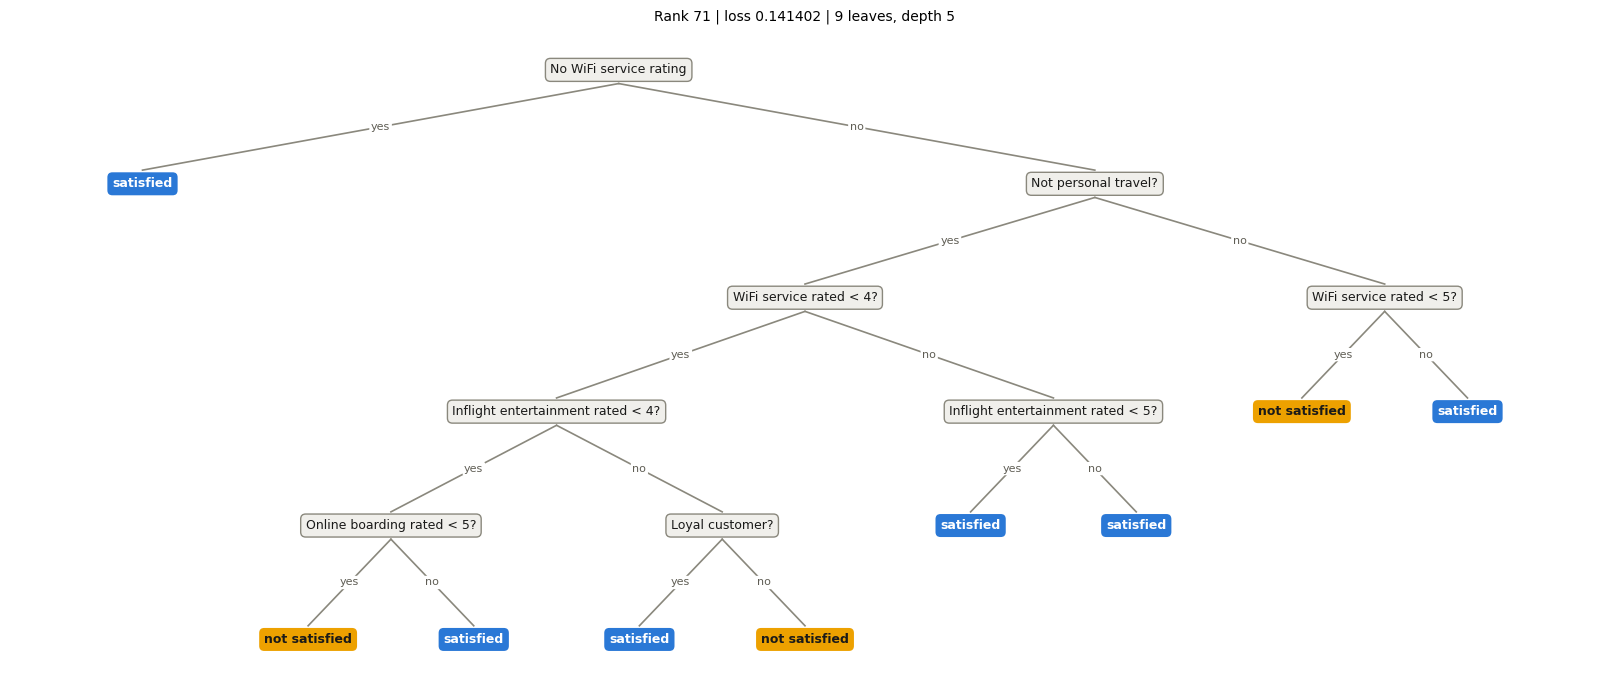

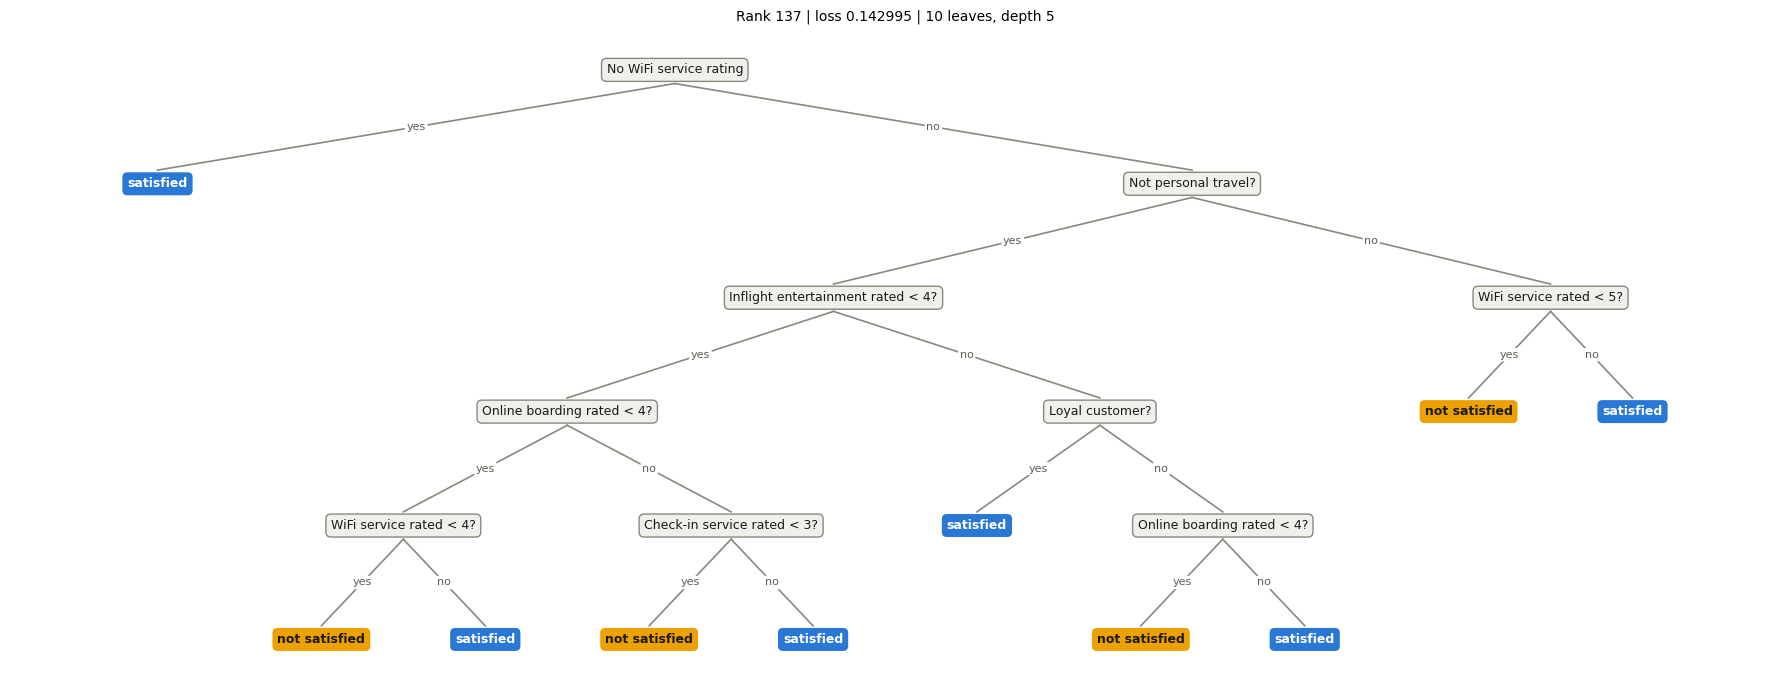

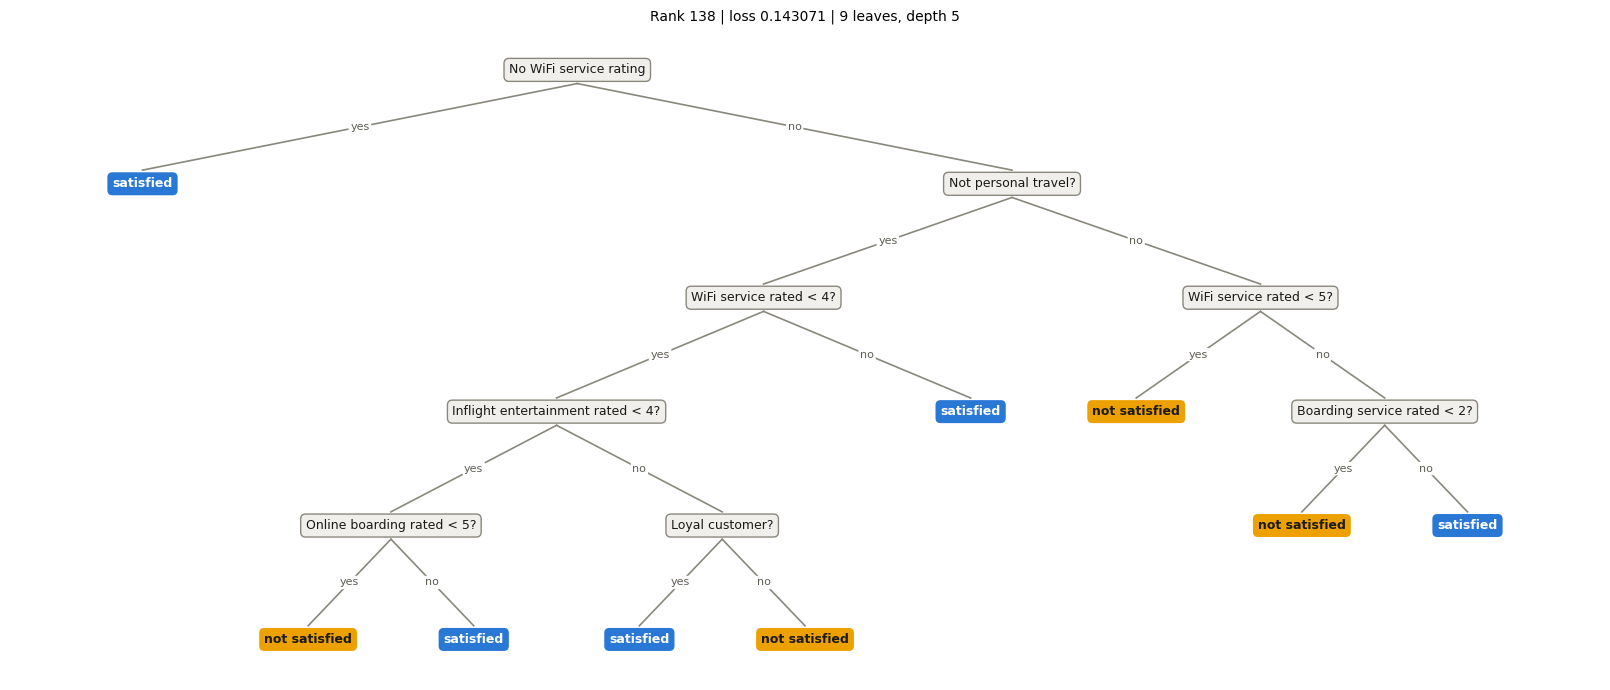

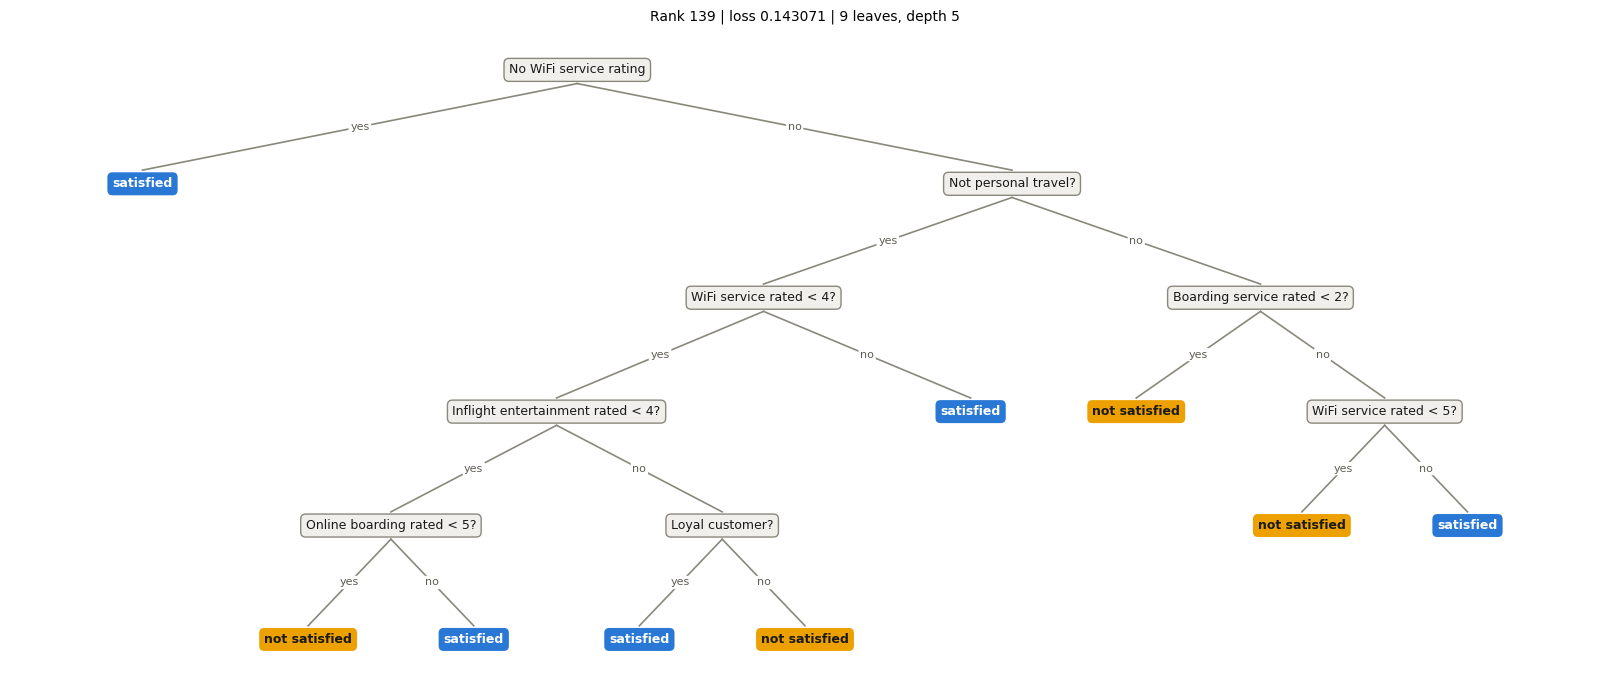

In [6]:
import matplotlib.pyplot as plt

n = len(trees)
sample_ranks = sorted({0, 1, 2, n // 2 - 1, n // 2, n // 2 + 1, n - 3, n - 2, n - 1})

for r in sample_ranks:
    draw_tree(trees[r], feature_names, feature_labels=feature_labels)
    plt.tight_layout()
    plt.show()

## Takeaways

*(fill in after inspecting the diagrams)*

- Depth / number of leaves: did they change gradually or abruptly across the set?
- Split variables: which changed between adjacent samples, and where in the tree (root vs near-leaf)?
- Split thresholds on binarized continuous variables (e.g. `Inflight_wifi_service <= 3.5` vs `<= 4.5`): jiggled slightly or swapped entirely?
- Are any splits derived from continuous variables vs one-hot categoricals?